In [1]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data virtualisation
import matplotlib.pyplot as plt 
import seaborn as sns

# Import machine learning tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import machine learning models
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Import evaluation metrics
from sklearn.metrics  import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

#Library for saving models
import joblib 

In [2]:
#Load the dataset
data = pd.read_csv("heart_disease_uci.csv")
print(data.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


## 📊 Exploratory Data Analysis (EDA)

Understanding the distribution of features and their relationship with the target variable.

/tmp/ipykernel_64184/2392114094.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=data, palette='viridis')


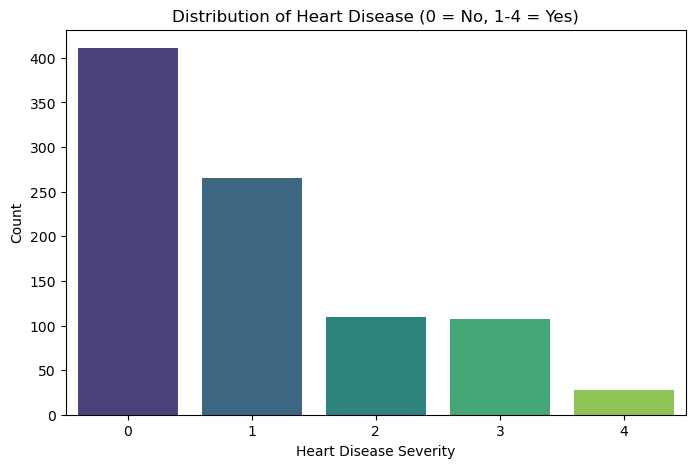

In [3]:
# Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='num', data=data, palette='viridis')
plt.title('Distribution of Heart Disease (0 = No, 1-4 = Yes)')
plt.xlabel('Heart Disease Severity')
plt.ylabel('Count')
plt.show()

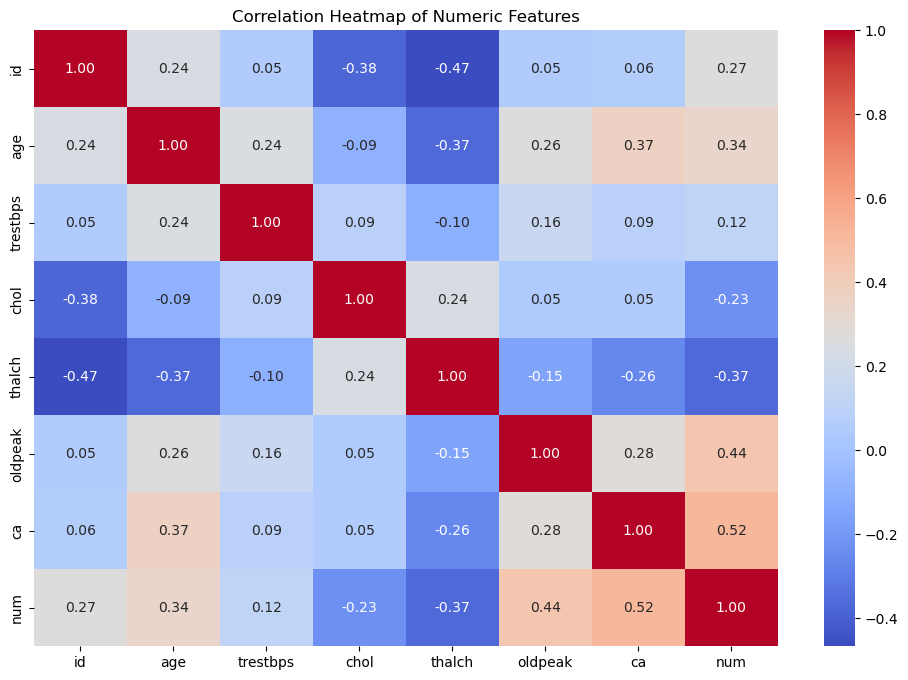

In [4]:
# Correlation Heatmap (Numeric Features Only)
plt.figure(figsize=(12, 8))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

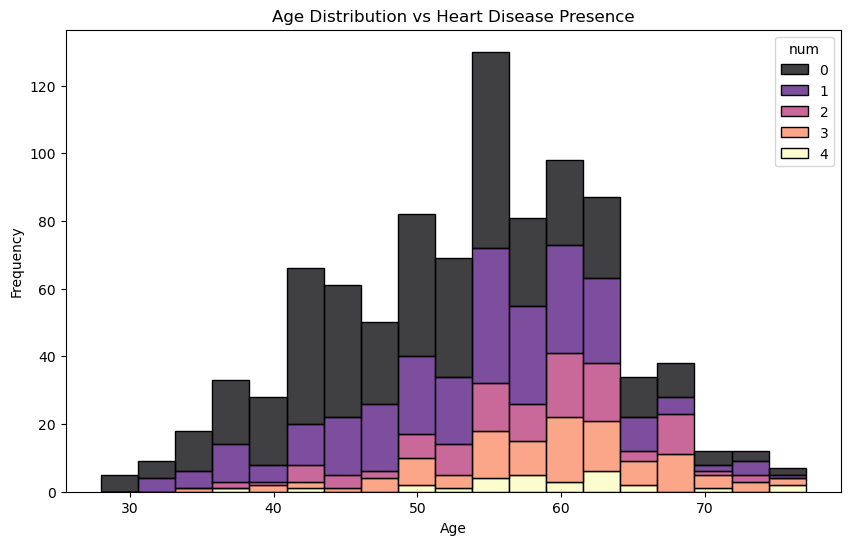

In [5]:
# Age Distribution vs Heart Disease
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='age', hue='num', multiple='stack', palette='magma')
plt.title('Age Distribution vs Heart Disease Presence')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [7]:
# Handle Missing Values
data.fillna(data.median(numeric_only=True), inplace=True)


In [8]:
# Convert Target Variable to Binary
data['num'] = data['num'].apply(lambda x: 1 if x > 0 else 0)



In [9]:
# Drop Unnecessary Columns
data = data.drop(columns=['id','dataset'])


In [10]:
#Encode Categorical Variables
le = LabelEncoder()

categorical_columns = data.select_dtypes(include=['object']).columns

# One-hot encoding (correct way)
data = pd.get_dummies(data, drop_first=True)

# Verify all columns are numeric
print("\nUpdated Data Types")
print(data.dtypes)



Updated Data Types
age                           int64
trestbps                    float64
chol                        float64
thalch                      float64
oldpeak                     float64
ca                          float64
num                           int64
sex_Male                       bool
cp_atypical angina             bool
cp_non-anginal                 bool
cp_typical angina              bool
fbs_True                       bool
restecg_normal                 bool
restecg_st-t abnormality       bool
exang_True                     bool
slope_flat                     bool
slope_upsloping                bool
thal_normal                    bool
thal_reversable defect         bool
dtype: object


In [11]:
# 7️⃣ Define Features and Target

X = data.drop('num', axis=1)
y = data['num']

print("\nFeature Columns:", X.columns)




Feature Columns: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')


In [12]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,random_state=42, stratify=y
)


In [13]:
# Features (all except target column)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [14]:
#Initialize Models
log_model = LogisticRegression(max_iter=5000,  solver='liblinear')

svm_model = SVC(probability=True)

tree_model = DecisionTreeClassifier()

rf_model = RandomForestClassifier(
    n_estimators=700,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42
)

In [15]:
# Train models

log_model.fit(X_train, y_train)

svm_model.fit(X_train, y_train)

tree_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, min_samples_split=3, n_estimators=700,
                       random_state=42)

In [18]:
#Predictions
log_pred = log_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
tree_pred = tree_model.predict(X_test)
rf_pred = rf_model.predict(X_test)


In [17]:
# Model Accuracy

print("\nModel Accuracy Scores")

print("Logistic Regression:", accuracy_score(y_test, log_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("Decision Tree:", accuracy_score(y_test, tree_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))





Model Accuracy Scores
Logistic Regression: 0.8369565217391305
SVM: 0.842391304347826
Decision Tree: 0.7880434782608695
Random Forest: 0.842391304347826


In [19]:
# 🔟 Fixed Cross Validation (6 folds)
models = [log_model, svm_model, tree_model, rf_model]
model_names = ["Logistic Regression", "SVM", "Decision Tree", "Random Forest"]

print("\nCross Validation Scores")
for model, name in zip(models, model_names):
    scores = cross_val_score(model, X_train, y_train, cv=6)
    print(f"{name} Average Accuracy: {scores.mean():.4f}")



Cross Validation Scores
Logistic Regression Average Accuracy: 0.8179
SVM Average Accuracy: 0.8247
Decision Tree Average Accuracy: 0.7215
Random Forest Average Accuracy: 0.8206


## ⚙️ Hyperparameter Tuning (Random Forest)

Using GridSearchCV to find the best parameters for our top-performing model.

In [20]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)


Best Parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Score: 0.8260801617944475


## 📈 Advanced Evaluation (ROC-AUC)

Visualizing the model's ability to distinguish between classes.

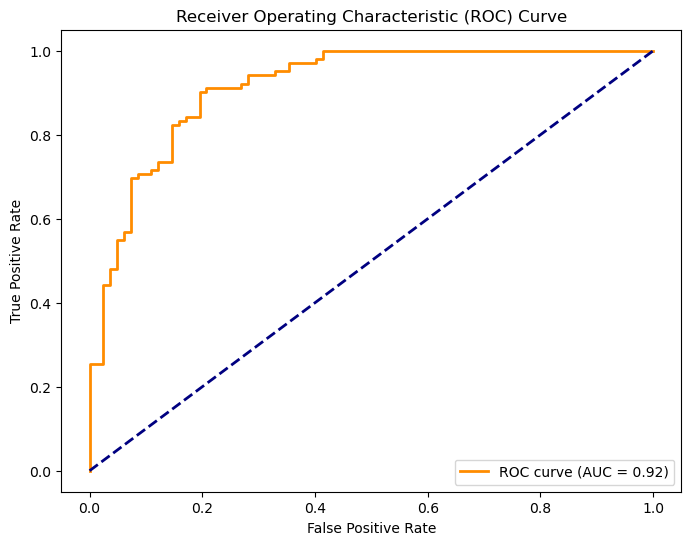

In [21]:
y_probs = best_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


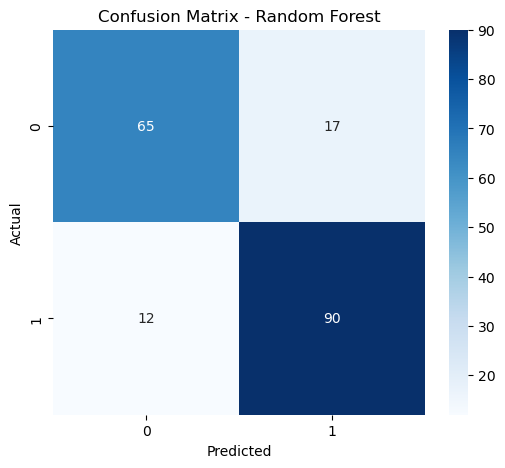

In [31]:
#Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [22]:
# Classification Report

print("\nRandom Forest Report\n")

print(classification_report(y_test, rf_pred))



Random Forest Report

              precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [23]:
# 💾 Save the Tuned Model
joblib.dump(best_rf, "heart_disease_model.pkl")
joblib.dump(scaler, "scaler.pkl") # Also save the scaler for preprocessing new inputs

print("\nTuned Model and Scaler saved!")


Tuned Model and Scaler saved!


## 🩺 Prediction for New Data

A helper function to predict heart disease for new patient data.

In [25]:
def predict_heart_disease(patient_data):
    # Convert data to DataFrame to match training columns
    patient_df = pd.DataFrame([patient_data])
    
    # Ensure all columns exist (even if not provided, fill with 0/False)
    for col in X.columns:
        if col not in patient_df.columns:
            patient_df[col] = 0
    
    # Reorder columns to match original X
    patient_df = patient_df[X.columns]
    
    # Scale data
    patient_scaled = scaler.transform(patient_df)
    
    # Predict probabilities
    prob = best_rf.predict_proba(patient_scaled)[0][1]
    risk = "High Risk" if prob > 0.5 else "Low Risk"
    
    return f"Prediction: {risk} ({prob*100:.2f}% Probability)"

# Example usage with sample values
example_patient = {
    'age': 55,
    'trestbps': 140,
    'chol': 250,
    'thalch': 150,
    'oldpeak': 1.5,
    'ca': 0,
    'sex_Male': 1,
    'cp_typical angina': 0,
    'exang_True': 1
}

print(predict_heart_disease(example_patient))

Prediction: High Risk (87.21% Probability)


Exception ignored in: <function ResourceTracker.__del__ at 0x74feebe416c0>
Traceback (most recent call last):
  File "/home/bdtech/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/bdtech/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/bdtech/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f0fa743d6c0>
Traceback (most recent call last):
  File "/home/bdtech/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/bdtech/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/bdtech/anaconda3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__